# Annonces commerciales × Bilans : traitement

Ce notebook construit un jeu de données qui associe, pour une **même entreprise (SIREN)** et une **même année**,
les annonces BODACC de **radiation** et les bilans déposés.

Les fichiers sources sont lus dans le bucket S3 `raw` (Garage) et les résultats sont écrits dans le bucket `processed`.

<a id="sommaire"></a>
## Sommaire

0. [Paramètres et connexion S3](#parametres)
1. [Vérification des sources dans `s3://raw`](#ingestion)
2. [Nettoyage des annonces de radiation](#clean-annonces)
3. [Nettoyage des bilans](#clean-bilans)
4. [Jointure annonces × bilans (SIREN + année)](#jointure)
5. [Ratio d'impôt (HK / FL × 100)](#ratio-impot)
6. [Contrôles et récapitulatif](#controles)
7. [Évolution annuelle : ratio d'impôt et radiations](#evolution)

## Vue d'ensemble

```mermaid
flowchart LR
    R[annonces-commerciales_radiations] --> CA["Nettoyage annonces<br/>id, publicationavis, dateparution,<br/>familleavis, registre"]
    B[export-detail-bilan] --> CB["Nettoyage bilans<br/>– confidentiality"]
    CA --> J{"Jointure interne<br/>SIREN + année"}
    CB --> J
    J --> O[(s3://processed/annonces_bilans.parquet)]
    O --> RI["Ratio d'impôt<br/>HK / FL × 100"]
    RI --> O2[(s3://processed/annonces_bilans_ratio_impot.parquet)]
    O2 --> S["Statistiques annuelles<br/>+ graphiques"]
    CA --> S
```

> Les fichiers font plusieurs Go. Tout le traitement est fait avec **DuckDB**, qui lit et écrit le Parquet
> directement sur S3, en flux, sans tout charger en mémoire comme le ferait pandas.

<a id="parametres"></a>
## 0. Paramètres et connexion S3

- Les identifiants S3 sont fournis par `docker-compose` (variables `AWS_*`), il n'y a rien à saisir.
- `FICHIERS` donne le nom de chaque fichier source dans `s3://raw`.


<small>[↑ Retour au sommaire](#sommaire)</small>

In [1]:
import os

import boto3
import duckdb

BUCKET_RAW = "raw"
BUCKET_PROCESSED = "processed"

FICHIERS = {
    "radiations": "annonces-commerciales_radiations.parquet",
    "bilans": "export-detail-bilan.parquet",
}

S3 = lambda bucket, key: f"s3://{bucket}/{key}"

s3 = boto3.client("s3")

con = duckdb.connect()
con.sql("INSTALL httpfs; LOAD httpfs;")
con.sql(f"""
    CREATE OR REPLACE SECRET garage (
        TYPE s3,
        KEY_ID '{os.environ["AWS_ACCESS_KEY_ID"]}',
        SECRET '{os.environ["AWS_SECRET_ACCESS_KEY"]}',
        REGION '{os.environ["AWS_DEFAULT_REGION"]}',
        ENDPOINT '{os.environ["AWS_ENDPOINT_URL"].removeprefix("http://")}',
        URL_STYLE 'path',
        USE_SSL false
    )
""")
"Connexion OK"

'Connexion OK'

<a id="ingestion"></a>
## 1. Vérification des sources dans `s3://raw`

Les fichiers sources sont **téléchargés automatiquement par Airflow** (DAG `telecharger_sources`,
visible sur http://localhost:8080) au premier `docker compose up` :

| Fichier | Source |
|---|---|
| `annonces-commerciales_radiations.parquet` | BODACC, annonces de radiation |
| `export-detail-bilan.parquet` | data.gouv.fr, données financières détaillées des entreprises |

Le téléchargement prend quelques minutes (environ 3,7 Go au total). Cette cellule vérifie que les deux fichiers
sont bien arrivés avant de lancer le traitement.

<small>[↑ Retour au sommaire](#sommaire)</small>

In [2]:
manquants = []
for nom in FICHIERS.values():
    try:
        taille = s3.head_object(Bucket=BUCKET_RAW, Key=nom)["ContentLength"]
        print(f"présent : s3://{BUCKET_RAW}/{nom} ({taille / 1e9:.2f} Go)")
    except s3.exceptions.ClientError:
        manquants.append(nom)

if manquants:
    raise FileNotFoundError(
        f"Pas encore dans s3://{BUCKET_RAW} : {', '.join(manquants)}. "
        "Le DAG Airflow « telecharger_sources » est sans doute encore en cours : "
        "suis-le sur http://localhost:8080 et relance cette cellule quand il a terminé."
    )

présent : s3://raw/annonces-commerciales_radiations.parquet (0.86 Go)
présent : s3://raw/export-detail-bilan.parquet (2.82 Go)


<a id="clean-annonces"></a>
## 2. Nettoyage des annonces de radiation

On lit le fichier des radiations et on ne garde que les colonnes utiles :

| Colonne | Signification |
|---|---|
| `id` | identifiant unique de l'annonce |
| `publicationavis` | type de publication BODACC (A, B, C) |
| `dateparution` | date de parution de l'annonce |
| `familleavis` | famille d'avis (ici toujours `radiation`) |
| `registre` | n° RCS, sous la forme `"843 380 197,843380197"` |

Résultat : **`s3://processed/annonces_commerciales.parquet`**


<small>[↑ Retour au sommaire](#sommaire)</small>

In [3]:
con.sql(f"""
    CREATE OR REPLACE VIEW annonces AS
    SELECT id, publicationavis, dateparution, familleavis, registre
    FROM read_parquet('{S3(BUCKET_RAW, FICHIERS["radiations"])}')
""")
con.sql(f"COPY annonces TO '{S3(BUCKET_PROCESSED, 'annonces_commerciales.parquet')}' (FORMAT parquet)")
con.sql(f"SELECT * FROM '{S3(BUCKET_PROCESSED, 'annonces_commerciales.parquet')}' LIMIT 5")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────┬─────────────────┬──────────────┬─────────────┬───────────────────────┐
│     id      │ publicationavis │ dateparution │ familleavis │       registre        │
│   varchar   │     varchar     │     date     │   varchar   │        varchar        │
├─────────────┼─────────────────┼──────────────┼─────────────┼───────────────────────┤
│ B2025001917 │ B               │ 2025-01-28   │ radiation   │ 520655226,520 655 226 │
│ B2025001957 │ B               │ 2025-01-28   │ radiation   │ 852216183,852 216 183 │
│ B2025001964 │ B               │ 2025-01-28   │ radiation   │ 982173627,982 173 627 │
│ B2025001971 │ B               │ 2025-01-28   │ radiation   │ 502091200,502 091 200 │
│ B2025001983 │ B               │ 2025-01-28   │ radiation   │ 919093328,919 093 328 │
└─────────────┴─────────────────┴──────────────┴─────────────┴───────────────────────┘

<a id="clean-bilans"></a>
## 3. Nettoyage des bilans

On retire la colonne `confidentiality` et on garde toutes les autres :

| Colonne | Signification |
|---|---|
| `siren` | SIREN de l'entreprise (9 chiffres) |
| `date_cloture_exercice` | date de clôture de l'exercice comptable |
| `type_bilan` | `C` complet, `S` simplifié, `K` consolidé |
| `liasse` | postes de la liasse fiscale (code → montant) |

Résultat : **`s3://processed/bilans.parquet`**


<small>[↑ Retour au sommaire](#sommaire)</small>

In [4]:
con.sql(f"""
    CREATE OR REPLACE VIEW bilans AS
    SELECT * EXCLUDE (confidentiality)
    FROM read_parquet('{S3(BUCKET_RAW, FICHIERS["bilans"])}')
""")
con.sql(f"COPY bilans TO '{S3(BUCKET_PROCESSED, 'bilans.parquet')}' (FORMAT parquet)")
con.sql(f"SELECT * FROM '{S3(BUCKET_PROCESSED, 'bilans.parquet')}' LIMIT 5")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌───────────┬───────────────────────┬────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

<a id="jointure"></a>
## 4. Jointure annonces × bilans (SIREN + année)

**Clés de jointure**

- **SIREN** : les annonces n'ont pas de colonne `siren`. On l'extrait de `registre`, qui contient le numéro
  deux fois, avec et sans espaces, dans un ordre qui varie (`"843 380 197,843380197"` ou `"520655226,520 655 226"`).
  On supprime les espaces, puis on prend la première suite de 9 chiffres.
- **Année** : `année(dateparution)` côté annonces, `année(date_cloture_exercice)` côté bilans.

**Jointure interne (`INNER JOIN`)** : une ligne n'est gardée que si le couple *(SIREN, année)* existe
**dans les deux fichiers**. Les annonces sans bilan cette année-là et les bilans sans annonce sont retirés.

> ⚠️ Une entreprise peut déposer plusieurs bilans la même année (par exemple un complet et un consolidé).
> Une annonce apparaît alors **une fois par bilan** correspondant.

Résultat : **`s3://processed/annonces_bilans.parquet`**


<small>[↑ Retour au sommaire](#sommaire)</small>

In [5]:
con.sql(f"""
    CREATE OR REPLACE VIEW annonces_bilans AS
    WITH a AS (
        SELECT *,
               regexp_extract(replace(registre, ' ', ''), '(\\d{{9}})', 1) AS siren,
               year(dateparution) AS annee
        FROM read_parquet('{S3(BUCKET_PROCESSED, 'annonces_commerciales.parquet')}')
    ),
    b AS (
        SELECT *, year(date_cloture_exercice) AS annee
        FROM read_parquet('{S3(BUCKET_PROCESSED, 'bilans.parquet')}')
    )
    SELECT a.*, b.* EXCLUDE (siren, annee)
    FROM a
    INNER JOIN b USING (siren, annee)
""")
con.sql(f"COPY annonces_bilans TO '{S3(BUCKET_PROCESSED, 'annonces_bilans.parquet')}' (FORMAT parquet)")
con.sql(f"SELECT * FROM '{S3(BUCKET_PROCESSED, 'annonces_bilans.parquet')}' LIMIT 5")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌───────────────┬─────────────────┬──────────────┬─────────────┬───────────────────────┬───────────┬───────┬───────────────────────┬────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│      id       │ publicati

<a id="ratio-impot"></a>
## 5. Ratio d'impôt (HK / FL × 100)

$$\text{ratio\_impot} = \frac{HK}{FL} \times 100$$

| Code liasse | Signification |
|---|---|
| `HK` | impôts sur les bénéfices |
| `FL` | chiffre d'affaires net total |

Les deux montants sont lus dans la colonne `liasse` (code → montant) et ajoutés au résultat dans les colonnes `hk` et `fl`.

**Cas particuliers**

- **Ratio vide (`NULL`)** si `HK` ou `FL` est absent, ou si `FL = 0` (division impossible).
- **Bilans simplifiés (`type_bilan = 'S'`)** : ils n'utilisent pas les codes `HK`/`FL` (liasse 2033), leur ratio est donc toujours vide.
- **Ratio négatif** : `HK` négatif, c'est-à-dire un crédit d'impôt (par exemple un CIR) supérieur à l'impôt dû. Ces lignes sont conservées.

Résultat : **`s3://processed/annonces_bilans_ratio_impot.parquet`**

<small>[↑ Retour au sommaire](#sommaire)</small>

In [6]:
con.sql(f"""
    CREATE OR REPLACE VIEW annonces_bilans_ratio_impot AS
    SELECT *,
           CASE WHEN fl <> 0 THEN 100.0 * hk / fl END AS ratio_impot
    FROM (
        SELECT *, liasse['HK'] AS hk, liasse['FL'] AS fl
        FROM read_parquet('{S3(BUCKET_PROCESSED, 'annonces_bilans.parquet')}')
    )
""")
con.sql(f"COPY annonces_bilans_ratio_impot TO '{S3(BUCKET_PROCESSED, 'annonces_bilans_ratio_impot.parquet')}' (FORMAT parquet)")
con.sql(f"""
    SELECT id, siren, annee, type_bilan, hk, fl, round(ratio_impot, 2) AS ratio_impot
    FROM '{S3(BUCKET_PROCESSED, 'annonces_bilans_ratio_impot.parquet')}'
    WHERE ratio_impot IS NOT NULL
    LIMIT 10
""")

┌───────────────┬───────────┬───────┬────────────┬─────────┬──────────┬─────────────┐
│      id       │   siren   │ annee │ type_bilan │   hk    │    fl    │ ratio_impot │
│    varchar    │  varchar  │ int64 │  varchar   │  int32  │  int32   │   double    │
├───────────────┼───────────┼───────┼────────────┼─────────┼──────────┼─────────────┤
│ B201801822263 │ 420052524 │  2018 │ C          │    3336 │     3816 │       87.42 │
│ B201901814900 │ 420180614 │  2019 │ C          │  160826 │  4191807 │        3.84 │
│ B20100085297  │ 420210577 │  2010 │ C          │     806 │   156270 │        0.52 │
│ B201702432079 │ 420284416 │  2017 │ C          │ 4376579 │   827305 │      529.02 │
│ B201601881598 │ 421193293 │  2016 │ C          │     906 │   296125 │        0.31 │
│ B202002523580 │ 421203456 │  2020 │ C          │    1526 │    42750 │        3.57 │
│ B201600042441 │ 421411828 │  2016 │ C          │   13789 │   211168 │        6.53 │
│ B201600162835 │ 421411828 │  2016 │ C          │   1

Répartition du ratio par type de bilan : combien de lignes ont un ratio calculable, et ses quartiles.

In [7]:
con.sql(f"""
    SELECT type_bilan,
           count(*) AS lignes,
           count(ratio_impot) AS avec_ratio,
           round(quantile_cont(ratio_impot, 0.25), 2) AS q1,
           round(median(ratio_impot), 2) AS mediane,
           round(quantile_cont(ratio_impot, 0.75), 2) AS q3
    FROM '{S3(BUCKET_PROCESSED, 'annonces_bilans_ratio_impot.parquet')}'
    GROUP BY type_bilan ORDER BY type_bilan
""").df()

,type_bilan,lignes,avec_ratio,q1,mediane,q3
0,C,5863,1889,0.13,1.16,4.02
1,K,5,4,-0.49,-0.24,4.69
2,S,4232,0,NaN,NaN,NaN


<a id="controles"></a>
## 6. Contrôles et récapitulatif

Nombre de lignes à chaque étape, et part des annonces dont on n'a pas pu extraire de SIREN
(`registre` vide ou mal formé) : ces annonces ne peuvent pas être jointes.


<small>[↑ Retour au sommaire](#sommaire)</small>

In [8]:
con.sql(f"""
    SELECT 'annonces de radiation' AS etape,
           count(*) AS lignes FROM '{S3(BUCKET_PROCESSED, 'annonces_commerciales.parquet')}'
    UNION ALL
    SELECT 'annonces sans SIREN exploitable',
           count(*) FILTER (WHERE regexp_extract(replace(coalesce(registre, ''), ' ', ''), '(\\d{{9}})', 1) = '')
           FROM '{S3(BUCKET_PROCESSED, 'annonces_commerciales.parquet')}'
    UNION ALL
    SELECT 'bilans', count(*) FROM '{S3(BUCKET_PROCESSED, 'bilans.parquet')}'
    UNION ALL
    SELECT 'annonces × bilans (jointure)', count(*) FROM '{S3(BUCKET_PROCESSED, 'annonces_bilans.parquet')}'
    UNION ALL
    SELECT '… dont avec ratio d''impôt calculable', count(ratio_impot)
           FROM '{S3(BUCKET_PROCESSED, 'annonces_bilans_ratio_impot.parquet')}'
""")

┌──────────────────────────────────────┬─────────┐
│                etape                 │ lignes  │
│               varchar                │  int64  │
├──────────────────────────────────────┼─────────┤
│ annonces de radiation                │ 4272554 │
│ annonces sans SIREN exploitable      │       3 │
│ bilans                               │ 6368964 │
│ annonces × bilans (jointure)         │   10100 │
│ … dont avec ratio d'impôt calculable │    1893 │
└──────────────────────────────────────┴─────────┘

In [9]:
con.sql(f"""
    SELECT familleavis, annee, count(*) AS lignes
    FROM '{S3(BUCKET_PROCESSED, 'annonces_bilans.parquet')}'
    GROUP BY ALL ORDER BY familleavis, annee
""").df()

,familleavis,annee,lignes
0,radiation,2010,1
1,radiation,2012,3
2,radiation,2013,15
3,radiation,2014,41
4,radiation,2015,176
5,radiation,2016,719
6,radiation,2017,1184
7,radiation,2018,1057
8,radiation,2019,1124
9,radiation,2020,862


<a id="evolution"></a>
## 7. Évolution annuelle : ratio d'impôt et radiations

Pour chaque année, on calcule :

| Colonne | Calcul | Population |
|---|---|---|
| `radiations` | nombre d'annonces de radiation publiées | toutes les radiations |
| `radiations_par_mois` | `radiations` ÷ nombre de mois publiés dans l'année | toutes les radiations |
| `bilans_avec_ratio` | nombre de lignes avec un ratio calculable | résultat de la jointure (étape 5) |
| `ratio_moyen` | moyenne de `ratio_impot` (en %) | résultat de la jointure (étape 5) |
| `ratio_median` | médiane de `ratio_impot` (en %) | résultat de la jointure (étape 5) |

**Pourquoi une moyenne *par mois* pour les radiations ?** L'année en cours n'est pas terminée. Diviser par le
nombre de mois publiés permet de la comparer aux années complètes.

**Pourquoi afficher aussi la médiane ?** Quand le chiffre d'affaires (`FL`) est très faible, le ratio devient
extrême (de −12 000 % à +4 000 %). Quelques lignes suffisent alors à tirer la moyenne. La médiane n'est pas
sensible à ces valeurs : si les deux courbes s'écartent beaucoup, la moyenne de l'année est due à quelques cas
atypiques.

> Avant 2016, il y a moins de 30 ratios par an (colonne `bilans_avec_ratio`) : ces années sont peu représentatives.

Résultat : **`s3://processed/stats_annuelles.parquet`**

<small>[↑ Retour au sommaire](#sommaire)</small>

In [10]:
con.sql(f"""
    CREATE OR REPLACE VIEW stats_annuelles AS
    WITH rad AS (
        SELECT year(dateparution) AS annee,
               count(*) AS radiations,
               count(DISTINCT month(dateparution)) AS mois_publies
        FROM '{S3(BUCKET_PROCESSED, 'annonces_commerciales.parquet')}'
        GROUP BY 1
    ),
    ratio AS (
        SELECT annee,
               count(ratio_impot) AS bilans_avec_ratio,
               avg(ratio_impot) AS ratio_moyen,
               median(ratio_impot) AS ratio_median
        FROM '{S3(BUCKET_PROCESSED, 'annonces_bilans_ratio_impot.parquet')}'
        WHERE ratio_impot IS NOT NULL
        GROUP BY 1
    )
    SELECT annee, radiations, mois_publies,
           radiations / mois_publies AS radiations_par_mois,
           coalesce(bilans_avec_ratio, 0) AS bilans_avec_ratio,
           ratio_moyen, ratio_median
    FROM rad LEFT JOIN ratio USING (annee)
    ORDER BY annee
""")
con.sql(f"COPY stats_annuelles TO '{S3(BUCKET_PROCESSED, 'stats_annuelles.parquet')}' (FORMAT parquet)")
stats = con.sql(f"SELECT * FROM '{S3(BUCKET_PROCESSED, 'stats_annuelles.parquet')}' ORDER BY annee").df()
stats.round(2)

,annee,radiations,mois_publies,radiations_par_mois,bilans_avec_ratio,ratio_moyen,ratio_median
0,2008,198900,12,16575.00,0,NaN,NaN
1,2009,171687,12,14307.25,0,NaN,NaN
2,2010,170959,12,14246.58,1,0.52,0.52
3,2011,163366,12,13613.83,0,NaN,NaN
4,2012,157804,12,13150.33,1,4.42,4.42
5,2013,160604,12,13383.67,3,0.47,0.70
6,2014,150080,12,12506.67,7,2.79,1.56
7,2015,159840,12,13320.00,21,2.66,1.40
8,2016,175679,12,14639.92,139,1.09,0.60
9,2017,175541,12,14628.42,222,7.28,0.90


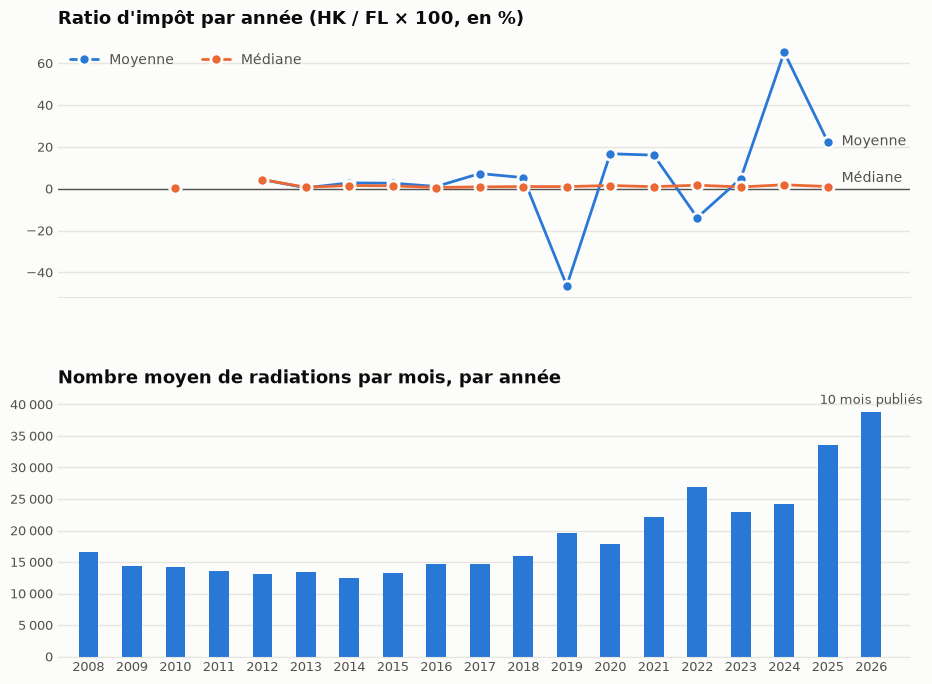

In [11]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

SURFACE, ENCRE, ENCRE_2, GRILLE = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e0"
BLEU, ORANGE = "#2a78d6", "#eb6834"
milliers = FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", " "))

fig, (ax_ratio, ax_rad) = plt.subplots(
    2, 1, figsize=(11, 8), sharex=True, facecolor=SURFACE, gridspec_kw={"hspace": 0.4}
)

# --- Ratio d'impôt moyen (et médiane pour comparaison) ---
r = stats[stats["annee"].between(stats.dropna(subset=["ratio_moyen"])["annee"].min(),
                                 stats.dropna(subset=["ratio_moyen"])["annee"].max())]  # années sans ratio = trou dans la courbe
ax_ratio.axhline(0, color=ENCRE_2, lw=1)
for col, couleur, nom in [("ratio_moyen", BLEU, "Moyenne"), ("ratio_median", ORANGE, "Médiane")]:
    ax_ratio.plot(r["annee"], r[col], color=couleur, lw=2, marker="o", ms=8,
                  mec=SURFACE, mew=2, solid_capstyle="round", solid_joinstyle="round", label=nom)
    ax_ratio.annotate(nom, (r["annee"].iloc[-1], r[col].iloc[-1]), xytext=(10, 6 if col == "ratio_median" else 0),
                      textcoords="offset points", va="center", color=ENCRE_2, fontsize=10)
ax_ratio.set_title("Ratio d'impôt par année (HK / FL × 100, en %)", loc="left",
                   color=ENCRE, fontsize=13, fontweight="bold", pad=12)
ax_ratio.legend(loc="upper left", frameon=False, ncol=2, labelcolor=ENCRE_2)

# --- Nombre moyen de radiations par mois ---
ax_rad.bar(stats["annee"], stats["radiations_par_mois"], width=0.45, color=BLEU)
ax_rad.yaxis.set_major_formatter(milliers)
ax_rad.set_title("Nombre moyen de radiations par mois, par année", loc="left",
                 color=ENCRE, fontsize=13, fontweight="bold", pad=12)
derniere = stats.iloc[-1]
if derniere["mois_publies"] < 12:
    ax_rad.annotate(f"{int(derniere['mois_publies'])} mois publiés", (derniere["annee"], derniere["radiations_par_mois"]),
                    xytext=(0, 6), textcoords="offset points", ha="center", color=ENCRE_2, fontsize=9)

for ax in (ax_ratio, ax_rad):
    ax.set_facecolor(SURFACE)
    ax.grid(axis="y", color=GRILLE, lw=1)
    ax.set_axisbelow(True)
    for cote in ("top", "right", "left"):
        ax.spines[cote].set_visible(False)
    ax.spines["bottom"].set_color(GRILLE)
    ax.tick_params(colors=ENCRE_2, labelsize=9, length=0)

ax_rad.set_xticks(stats["annee"])
ax_rad.set_xlim(stats["annee"].min() - 0.7, stats["annee"].max() + 0.9)
ax_rad.tick_params(axis="x", labelbottom=True)
plt.show()